In [1]:
# Imports
import numpy as np
from scipy.linalg import eig
import matplotlib.pyplot as plt

In [2]:
# Array of r values
R = 0.01
N = 50    # keep same domain extent r_max = 50
dr = R/N
r_values = np.arange(1, N+1) * dr + 1.

# Defining constants
U = 1
H = 1
kappa = np.ones(N) 
v_parallel = 1

# Equilibrium pressure and potential
L_p = 0.1
p_0 = 1. * np.exp(-(r_values-r_values[0])/L_p)

L_phi = 0.1
phi_0  = 0. * np.exp(-(r_values-r_values[0])/L_phi)

# Which mode
m = 1

# Matrix Helper Functions

In [3]:
def create_first_derivative_matrix(N, dx):
    matrix = np.zeros((N,N))

    for i in range(1, N-1, 1):
        matrix[i][i+1] = 1 
        matrix[i][i-1] = -1

    matrix[0][0] = -3 
    matrix[0][1] = 4
    matrix[0][2] = -1

    matrix[N-1][N-3] = 1 
    matrix[N-1][N-2] = -4
    matrix[N-1][N-1] = 3

    return matrix / (2 * dx)

def create_second_derivative_matrix(N, dx):
    matrix = np.zeros((N,N))

    for i in range(1, N-1, 1):
        matrix[i][i+1] = 1 
        matrix[i][i] = -2
        matrix[i][i-1] = 1

    matrix[0][0] = 2
    matrix[0][1] = -5
    matrix[0][2] = 4
    matrix[0][3] = -1

    matrix[N-1][N-4] = -1
    matrix[N-1][N-3] = 4
    matrix[N-1][N-2] = -5
    matrix[N-1][N-1] = 2

    return matrix / (dx ** 2)

def create_third_derivative_matrix(N, dx):
    matrix = np.zeros((N,N))

    for i in range(2, N-2, 1):
        matrix[i][i-2] = -1
        matrix[i][i-1] = 2
        matrix[i][i+1] = -2
        matrix[i][i+2] = 1

    matrix[0][0] = -5
    matrix[0][1] = 18
    matrix[0][2] = -24
    matrix[0][3] = 14
    matrix[0][4] = -3

    matrix[N-1][N-1] = 5
    matrix[N-1][N-2] = -18
    matrix[N-1][N-3] = 24
    matrix[N-1][N-4] = -14
    matrix[N-1][N-5] = 3

    matrix[1][0] = -3
    matrix[1][1] = 10
    matrix[1][2] = -12
    matrix[1][3] = 6
    matrix[1][4] = -1

    matrix[N-2][N-1] = 3
    matrix[N-2][N-2] = -10
    matrix[N-2][N-3] = 12
    matrix[N-2][N-4] = -6
    matrix[N-2][N-5] = 1

    return (matrix / (2 * (dx ** 3)))

def create_m_laplacian(N, dx, m, r_values):
    D1 = create_first_derivative_matrix(N, dx)
    D2 = create_second_derivative_matrix(N, dx)

    return (
        D2
        + np.diag(1 / r_values) @ D1
        - np.diag(m**2 / (r_values**2))
    )

# Dirichlet boundary conditions at edge
# NOTE: may want to impose boundary conditions for phi[0] later on....
# This is for eigenvalue problem gamma Ax = Bx, phi(r = R) = 0
def enforce_bc(A, B, N, dx):
    A[N-1][:] = 0
    B[N-1][:] = 0
    B[N-1][N-1] = 1

    B[0][:] = 0
    B[0][0] = 1
    A[0][:] = 0

    B[N][:] = 0
    B[N][N] = 1
    A[N][:] = 0

    # D1 = create_first_derivative_matrix(N, dx)
    # B[0][:] = np.concatenate([D1[0][:], np.zeros(N)])
    # A[0][:] = 0

    return A, B

## Linear Stability Operator

The eigenvalue problem to be solved is:

$$
\gamma
\begin{pmatrix} \Delta_m & 0 \\ 0 & 1 \end{pmatrix}
\begin{pmatrix} \hat\varphi \\ \hat\rho \end{pmatrix}
=
\begin{pmatrix} \mathcal{L}_{11} & \mathcal{L}_{12} \\ \mathcal{L}_{21} & \mathcal{L}_{22} \end{pmatrix}
\begin{pmatrix} \hat\varphi \\ \hat\rho \end{pmatrix}.
$$

### Linear operators (expanded form)

$$
\mathcal{L}_{11}
  = -im\Omega_0 \Delta_m
    + \frac{im}{r}(\Delta\varphi_0)'
    - \frac{imU}{r}\left(P_0''\frac{\partial}{\partial r} + P_0'\,\frac{\partial^2}{\partial r^2}\right)
    + \frac{im^3 U}{r^3}\,P_0'
    + H
    - \nu_\parallel \Delta_m,
$$

$$
\mathcal{L}_{12}
  = \frac{imU}{r}\left(\varphi_0''' + \varphi_0''\,\frac{\partial}{\partial r}\right) - 2im\mathcal{K},
$$

$$
\mathcal{L}_{21} = \frac{im}{r}P_0'(r),
$$

$$
\mathcal{L}_{22} = -\nu_\parallel^P - im\Omega_0(r).
$$

where
$$\Omega_0(r) \equiv \frac{1}{r}\frac{\partial \varphi_0}{\partial r}, \quad \text{where } \varphi_0 \text{ is the equilibrium potential.}$$

and 

$$
(\Delta\varphi_0)' = \varphi_0''' + \frac{\varphi_0''}{r} - \frac{\varphi_0'}{r^2}.
$$

### Linear operators (for benchmarking purposes we drop sources, parallel/perpendicular loss, FLR effects, line tying effects)

$$
\mathcal{L}_{11}
  = -im\Omega_0 \Delta_m
    + \frac{im}{r}(\Delta\varphi_0)'
$$

$$
\mathcal{L}_{12}
  = - 2im\mathcal{K},
$$

$$
\mathcal{L}_{21} = \frac{im}{r}P_0'(r),
$$

$$
\mathcal{L}_{22} = - im\Omega_0(r).
$$

where
$$\Omega_0(r) \equiv \frac{1}{r}\frac{\partial \varphi_0}{\partial r}, \quad \text{where } \varphi_0 \text{ is the equilibrium potential.}$$

and 

$$
(\Delta\varphi_0)' = \varphi_0''' + \frac{\varphi_0''}{r} - \frac{\varphi_0'}{r^2}.
$$

In [4]:
# Initalizing matrices
D1 = create_first_derivative_matrix(N, dr)
D2 = create_second_derivative_matrix(N, dr)
D3 = create_third_derivative_matrix(N, dr)
Dm = create_m_laplacian(N, dr, m, r_values)

diag_r = np.diag(r_values)
diag_div_r = np.diag(1 / r_values)

omega_0_diag = diag_div_r @ np.diag(D1 @ phi_0)
D_phi_prime_diag = np.diag((D3 + diag_div_r @ D2 - np.diag(1 / (r_values ** 2)) @ D1) @ phi_0)

# Defining opereators
L11 = (-1j * m * omega_0_diag @ Dm 
       + 1j * m * diag_div_r @ D_phi_prime_diag)

L12 = - 2j * m * np.diag(kappa)
L21 = 1j * m * np.diag(1 / r_values) @ np.diag(D1 @ p_0)
L22 = - (1j * m * omega_0_diag)

In [5]:
# Reduce eigenvalue problem to gamma * Ax = Bx

A = np.block([
    [Dm, np.zeros((N,N))],
    [np.zeros((N,N)), np.eye(N)]
])

B = np.block([
    [L11, L12],
    [L21, L22]
])

A, B = enforce_bc(A, B, N, dr)

In [6]:
eigenvalues, eigenvectors = eig(B, A)

# Each column of eigenvectors is an eigenvector
x0 = eigenvectors[:, 0]  # eigenvector for eigenvalues[0]

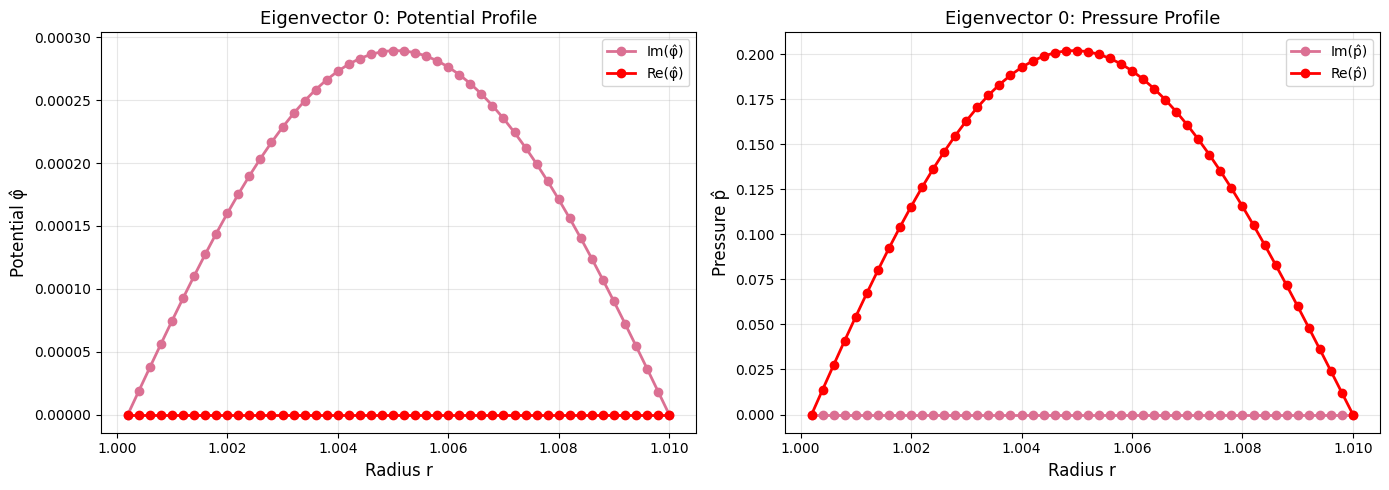

In [7]:
# Eigenvalue for null space vectors are inf, so we only look at the finite eigenvalues
finite_mask = np.isfinite(eigenvalues)
finite_evals = eigenvalues[finite_mask]
finite_indices = np.where(finite_mask)[0]
eigenvector_index = finite_indices[np.argmax(np.real(finite_evals))]
# eigenvector_index = 15

eigenvector = eigenvectors[:, eigenvector_index]
potential = eigenvector[:N]
pressure = eigenvector[N:2*N]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot potential
ax1.plot(r_values, np.imag(potential), 'o-', linewidth=2, label='Im(φ̂)', color='palevioletred')
ax1.plot(r_values, np.real(potential), 'o-',linewidth=2, label='Re(φ̂)', color='red')
ax1.set_xlabel('Radius r', fontsize=12)
ax1.set_ylabel('Potential φ̂', fontsize=12)
ax1.set_title(f'Eigenvector {eigenvector_index}: Potential Profile', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot pressure
ax2.plot(r_values, np.imag(pressure), 'o-', linewidth=2, label='Im(p̂)', color='palevioletred')
ax2.plot(r_values, np.real(pressure), 'o-',linewidth=2, label='Re(p̂)', color='red')
ax2.set_xlabel('Radius r', fontsize=12)
ax2.set_ylabel('Pressure p̂', fontsize=12)
ax2.set_title(f'Eigenvector {eigenvector_index}: Pressure Profile', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

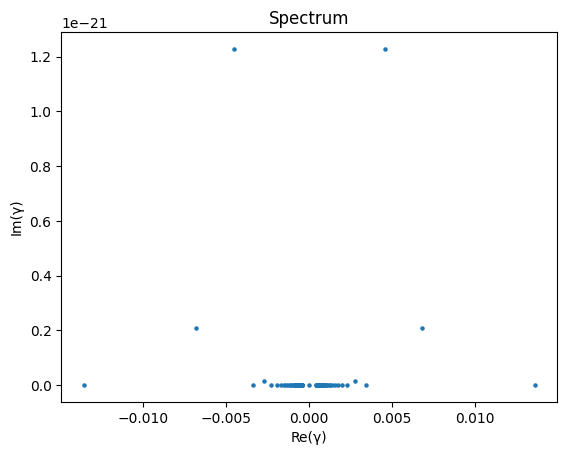

In [8]:
plt.scatter(np.real(finite_evals), np.imag(finite_evals), s=5)
plt.xlabel("Re(γ)"); plt.ylabel("Im(γ)")
plt.title("Spectrum")
plt.show()

## Testing m scaling

In [9]:
import numpy as np
from scipy.linalg import eig

m_values = np.arange(1, 50)
gamma_values = np.zeros(m_values.shape)

R = 0.1
N = 50    # keep same domain extent r_max = 50
dr = R/N
r_values = np.arange(1, N+1) * dr + 1.

kappa = np.ones(N)

# Equilibrium pressure and potential
L_p = 0.1
p_0  = 1. * np.exp(-(r_values-r_values[0])/L_p)

L_phi = 0.1
phi_0 = 0.05 * np.exp(-(r_values-r_values[0])/L_phi)

for i in range(len(m_values)):
    m = m_values[i]

    print(f"m = {m} / {m_values[-1]}", end='\r')

    # Initalizing matrices
    D1 = create_first_derivative_matrix(N, dr)
    D2 = create_second_derivative_matrix(N, dr)
    D3 = create_third_derivative_matrix(N, dr)
    Dm = create_m_laplacian(N, dr, m, r_values)

    diag_r = np.diag(r_values)
    diag_div_r = np.diag(1 / r_values)

    omega_0_diag = diag_div_r @ np.diag(D1 @ phi_0)
    D_phi_prime_diag = np.diag((D3 + diag_div_r @ D2 - np.diag(1 / (r_values ** 2)) @ D1) @ phi_0)

    # Defining opereators
    L11 = (-1j * m * omega_0_diag @ Dm 
        + 1j * m * diag_div_r @ D_phi_prime_diag)

    L12 = - 2j * m * np.diag(kappa)
    L21 = 1j * m * np.diag(1 / r_values) @ np.diag(D1 @ p_0)
    L22 = - (1j * m * omega_0_diag)

    A = np.block([
    [Dm, np.zeros((N,N))],
    [np.zeros((N,N)), np.eye(N)]
    ])

    B = np.block([
        [L11, L12],
        [L21, L22]
    ])

    A, B = enforce_bc(A, B, N, dr)

    eigenvalues, eigenvectors = eig(B, A)

    finite_mask = np.isfinite(eigenvalues)
    finite_evals = eigenvalues[finite_mask]

    gamma_values[i] = np.max(np.real(finite_evals))

In [10]:
def gamma(m, kx, kappa, p0, phi0, r, Lp, Lphi):

    ky = m/r
    k2 = kx**2. + ky**2.

    return m / (2*k2) * np.sqrt(8*k2*kappa*p0/(r*Lp) - phi0**2. / (r**2. * Lphi**6))

kx = 2 * np.pi / (2*R)
gamma_analytical = gamma(m_values, kx=kx, kappa=1, p0=p_0.mean(), phi0=phi_0.mean(), r=r_values.mean(), Lp=L_p, Lphi=L_phi)

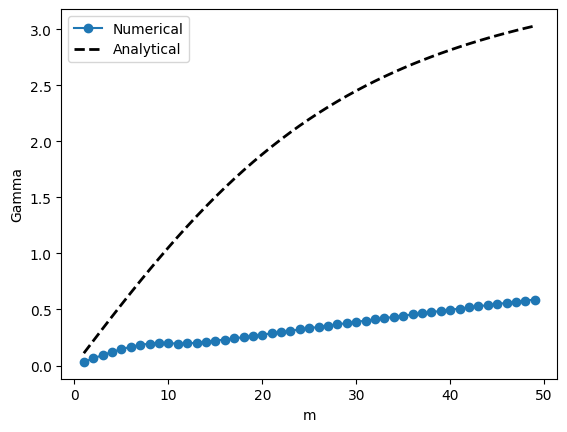

In [11]:
plt.plot(m_values, gamma_values, 'o-', label='Numerical')
plt.plot(m_values, gamma_analytical, 'k--', lw=2, label='Analytical')
plt.xlabel('m')
plt.ylabel('Gamma')
plt.legend()